# PPO 算法解决 CartPole 倒立摆问题

本 Notebook 展示了如何使用 Proximal Policy Optimization (PPO) 算法来训练一个智能体控制 CartPole。
我们将利用自定义的 `utils.py` 工具库来简化代码结构。

In [1]:
import gymnasium as gym # 导入 OpenAI Gym 库
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import utils  # 导入我们自定义的工具库
from IPython.display import clear_output    # 用于在 Jupyter Notebook 中清除输出
import time

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. 定义策略网络 (Actor) 和 价值网络 (Critic)
- **PolicyNet**: 输入状态，输出动作概率。
- **ValueNet**: 输入状态，输出状态价值 (Value)。

In [2]:
class PolicyNet(torch.nn.Module):
    """
    PPO中的策略网络，用来输出在给定状态下采取各个动作的概率分布，相当于Actor。
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)

class ValueNet(torch.nn.Module):
    """
    PPO中的价值网络，用来估计给定状态的价值，相当于Critic。
    """
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

## 2. 定义 PPO 算法
这里实现了 PPO-Clip 算法的核心逻辑。
注意我们在 `update` 方法中调用了 `utils.compute_advantage` 来计算 GAE。

In [ ]:
class PPO:
    """
    PPO算法类
    采用了 Clip (截断) + Adaptive KL Penalty (自适应KL惩罚) 联合优化的方式。
    """
    def __init__(self, 
                 state_dim: int, 
                 hidden_dim: int, 
                 action_dim: int, 
                 actor_lr: float, 
                 critic_lr: float, 
                 lmbda: float, 
                 epochs: int, 
                 eps: float, 
                 gamma: float, 
                 device: torch.device,
                 optimizer: torch.optim.Optimizer,
                 kl_target: float = 0.01,
                 kl_beta: float = 0.5,
                 grad_norm: float = 0.5
                 ):
        
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        
        self.actor_optimizer = optimizer(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optimizer(self.critic.parameters(), lr=critic_lr)
        
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs
        self.eps = eps
        self.device = device
        self.grad_norm = grad_norm
        
        # KL Penalty 参数
        self.kl_target = kl_target
        self.kl_beta = kl_beta

    def take_action(self, state):
        state = torch.tensor(np.array([state]), dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    def update(self, transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_delta = td_target - self.critic(states)
        advantage = utils.compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)
        
        # 优势标准化
        advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
        
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()
        
        actor_loss_list = []
        critic_loss_list = []
        
        for _ in range(self.epochs):
            log_probs = torch.log(self.actor(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)
            
            # 1. 计算 Clip Loss
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage
            clip_loss = -torch.min(surr1, surr2)
            
            # 2. 计算 KL Penalty
            kl_div = torch.mean(old_log_probs - log_probs)
            kl_loss = self.kl_beta * kl_div
            
            # 总 Actor Loss = Clip Loss + KL Penalty
            actor_loss = torch.mean(clip_loss + kl_loss)
            
            critic_loss = torch.mean(F.mse_loss(self.critic(states), td_target.detach()))
            
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()
            critic_loss.backward()
            
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.grad_norm)
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.grad_norm)
            
            self.actor_optimizer.step()
            self.critic_optimizer.step()
            
            actor_loss_list.append(actor_loss.item())
            critic_loss_list.append(critic_loss.item())

        # --- 动态调整 Beta ---
        with torch.no_grad():
            new_log_probs = torch.log(self.actor(states).gather(1, actions))
            kl_d = torch.mean(old_log_probs - new_log_probs).item()
        
        if kl_d < self.kl_target / 1.5:
            self.kl_beta /= 2
        elif kl_d > self.kl_target * 1.5:
            self.kl_beta *= 2
            
        return {'actor_loss': np.mean(actor_loss_list),
                'critic_loss': np.mean(critic_loss_list),
                'kl_beta': self.kl_beta,
                'kl_d': kl_d,
                'kl_loss': kl_loss.item(),
                'clip_loss': torch.mean(clip_loss).item(),
                'ratio': torch.mean(ratio).item()
                }

## 3. 训练准备
设置超参数，初始化环境和智能体。
我们将 `num_episodes` 增加到了 500，以确保能够收敛。

In [5]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
optimizer = torch.optim.AdamW
eps = 0.2

env_name = 'CartPole-v1'
env = gym.make(env_name)

seed = 114514
torch.manual_seed(seed)
np.random.seed(seed)
env.reset(seed=seed)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# 实例化 PPO
# 这里使用了 Clip + Adaptive KL Penalty 联合优化的版本
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,
            epochs, eps, gamma, device, optimizer,
            kl_target=0.01,
            kl_beta=0.5)

## 4. 开始训练
直接调用 `utils.train_on_policy_agent` 进行训练。

In [6]:
return_list, stats = utils.train_on_policy_agent(env, agent, num_episodes)

Iteration 9: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s, episode=500, return=500.000]


## 5. 结果可视化
使用 `utils.moving_average` 平滑曲线，展示训练效果。

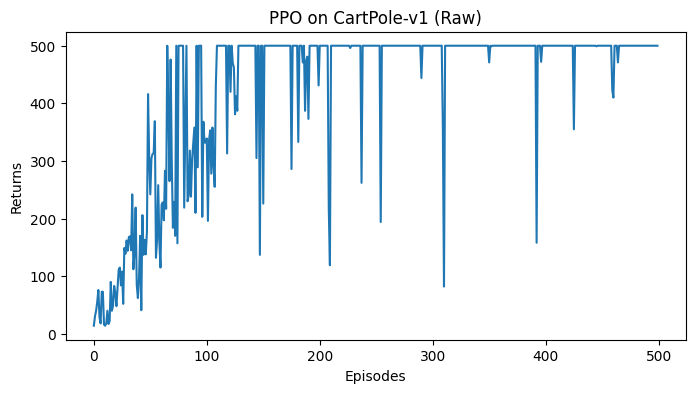

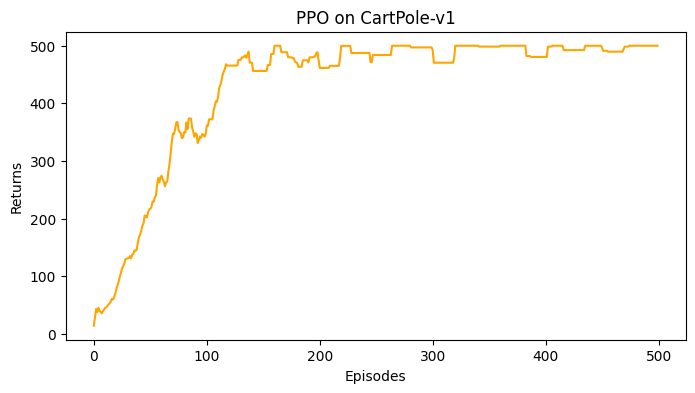

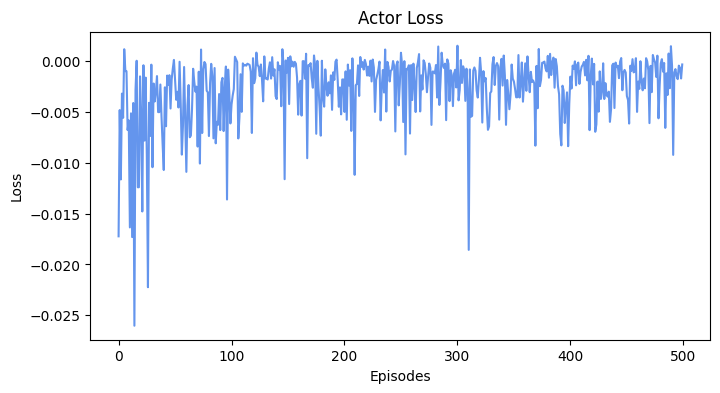

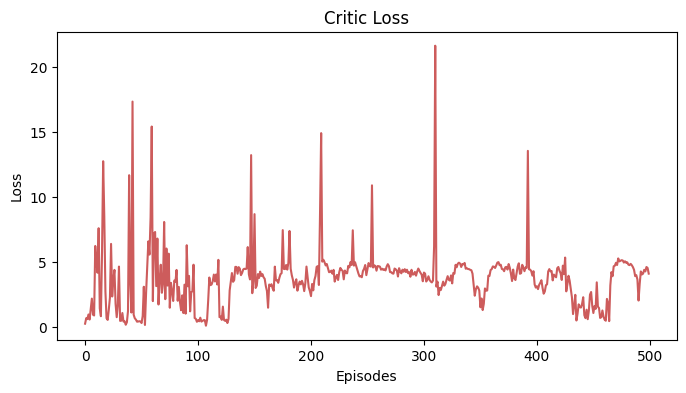

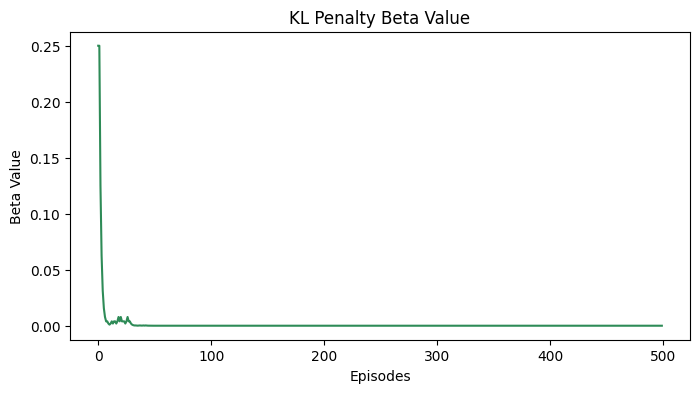

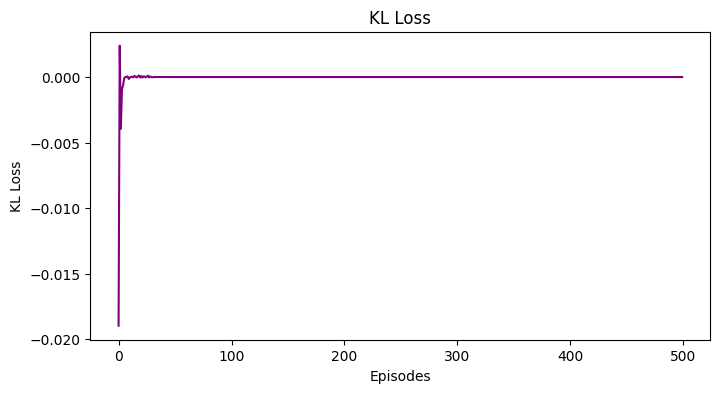

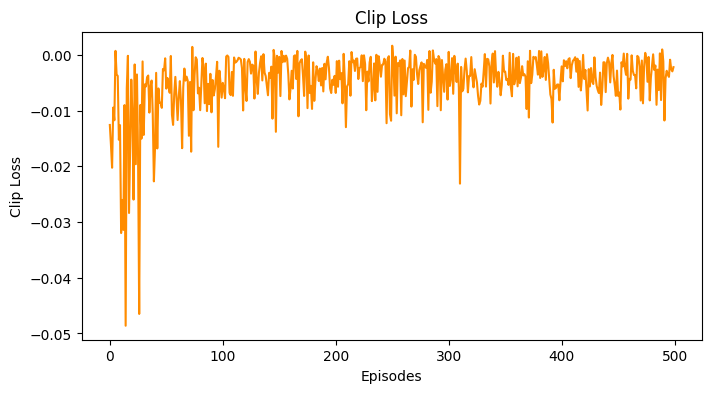

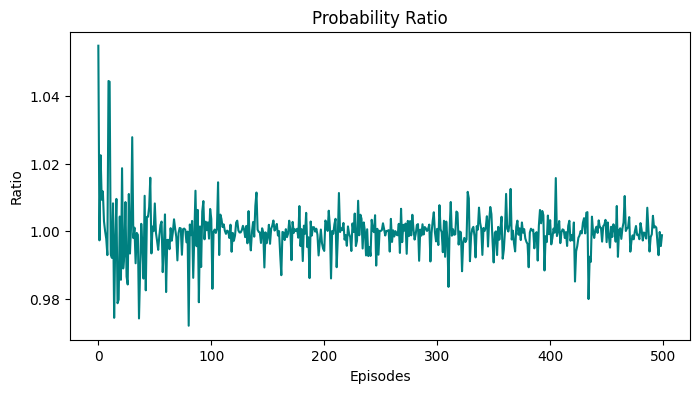

In [7]:
episodes_list = list(range(len(return_list)))

plt.style.use('default')

# 1. 绘制原始 Reward
plt.figure(figsize=(8, 4))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title(f'PPO on {env_name} (Raw)')
plt.savefig('./Figure/ppo_cartpole_returns_raw.png', dpi=300, transparent=True)
plt.show()

# 2. 绘制平滑 Reward
plt.figure(figsize=(8, 4))
mv_return = utils.moving_average(return_list, 19)
plt.plot(episodes_list, mv_return, color='orange')
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title(f'PPO on {env_name}')
plt.savefig('./Figure/ppo_cartpole_returns_smooth.png', dpi=300, transparent=True)
plt.show()

# 3. 绘制 Actor Loss
plt.figure(figsize=(8, 4))
plt.plot(stats['actor_loss'], color='cornflowerblue')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.title('Actor Loss')
plt.savefig('./Figure/ppo_cartpole_actor_loss.png', dpi=300, transparent=True)
plt.show()

# 4. 绘制 Critic Loss
plt.figure(figsize=(8, 4))
plt.plot(stats['critic_loss'], color='indianred')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.title('Critic Loss')
plt.savefig('./Figure/ppo_cartpole_critic_loss.png', dpi=300, transparent=True)
plt.show()

# 5. 绘制 Beta 变化
plt.figure(figsize=(8, 4))
plt.plot(stats['kl_beta'], color='seagreen')
plt.xlabel('Episodes')
plt.ylabel('Beta Value')
plt.title('KL Penalty Beta Value')
plt.savefig('./Figure/ppo_cartpole_kl_beta.png', dpi=300, transparent=True)
plt.show()

# 6. 绘制 KL loss 变化
plt.figure(figsize=(8, 4))
plt.plot(stats['kl_loss'], color='purple')
plt.xlabel('Episodes')
plt.ylabel('KL Loss')
plt.title('KL Loss')
plt.savefig('./Figure/ppo_cartpole_kl_loss.png', dpi=300, transparent=True)
plt.show()

# 7. 绘制 Clip loss 变化
plt.figure(figsize=(8, 4))
plt.plot(stats['clip_loss'], color='darkorange')
plt.xlabel('Episodes')
plt.ylabel('Clip Loss')
plt.title('Clip Loss')
plt.savefig('./Figure/ppo_cartpole_clip_loss.png', dpi=300, transparent=True)
plt.show()

# 8. 绘制 Ratio 变化
plt.figure(figsize=(8, 4))
plt.plot(stats['ratio'], color='teal')
plt.xlabel('Episodes')
plt.ylabel('Ratio')
plt.title('Probability Ratio')
plt.savefig('./Figure/ppo_cartpole_ratio.png', dpi=300, transparent=True)
plt.show()

## 6. 保存模型

In [9]:
# 保存模型参数到本地文件
model_filename = './Model/ppo_cartpole_model.pth'
torch.save(agent.actor.state_dict(), model_filename)

模型已保存为 ./Model/ppo_cartpole_model.pth
